# Schritt 1: Deep Q-Network (DQN) mit CartPole

## Warum kein Q-Tabellen-Ansatz mehr?

In K13_02 (Einarmiger Bandit) haben wir Schätzwerte für wenige Arme gelernt.
Was passiert, wenn der Zustandsraum kontinuierlich und riesig wird?

| Problem | Tabellen-Q-Learning | Deep Q-Network (DQN) |
|---------|--------------------|-----------------------|
| **Zustandsraum** | Muss diskret und endlich sein | Auch kontinuierlich möglich |
| **Skalierbarkeit** | Schach: >10^44 Zustände - unmöglich | Neuronales Netz approximiert Q-Funktion |
| **Generalisierung** | Kein Transfer zwischen ähnlichen Zuständen | Ähnliche Zustände -> ähnliche Q-Werte |

**CartPole**: Ein Pol balanciert auf einem Wagen. Zustand: 4 kontinuierliche Werte.
Aktionen: 2 (links/rechts). Ziel: Pol möglichst lange aufrecht halten.

## Lernziele

- Den Übergang von Q-Tabelle zu Deep Q-Network erklären können
- Die drei DQN-Kernkomponenten benennen und erläutern können
- Einen DQN-Agenten trainieren und die Lernkurve interpretieren können

## Leitfragen

- Was ist ein Q-Wert - und warum brauchen wir ein neuronales Netz dafür?
- Was ist Experience Replay - und warum stabilisiert es das Training?
- Was ist ein Target-Network - und warum ist es nötig?
- Wie erkennt man an der Lernkurve, dass der Agent dazulernt?

# Schritt 2: Installation und Imports

In [1]:
!pip install gymnasium -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque
import random
import time

import gymnasium as gym
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print("TensorFlow:", tf.__version__)
print("Gymnasium: ", gym.__version__)

TensorFlow: 2.20.0
Gymnasium:  1.3.0


# Schritt 3: Was ist CartPole? - Anschauliche Visualisierung

## Das Problem

Ein Wagen kann sich auf einer Schiene nach links oder rechts bewegen.
Auf dem Wagen ist ein Pol befestigt, der umfallen kann.

**Ziel des Agenten:** Den Pol durch Schieben des Wagens aufrecht halten.

## Die 4 Zustandsvariablen

| Variable | Bedeutung | Episode endet wenn... |
|----------|-----------|----------------------|
| x | Position des Wagens | abs(x) > 2.4 m |
| x' | Geschwindigkeit des Wagens | - |
| theta | Winkel des Pols | abs(theta) > 12 Grad |
| theta' | Winkelgeschwindigkeit | - |

**Reward:** +1 pro Schritt, in dem der Pol noch aufrecht steht. Maximum: 500 Schritte.

/tmp/ipykernel_1983/2152752247.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  cart = plt.Rectangle((x - cw/2, 0.02), cw, ch,


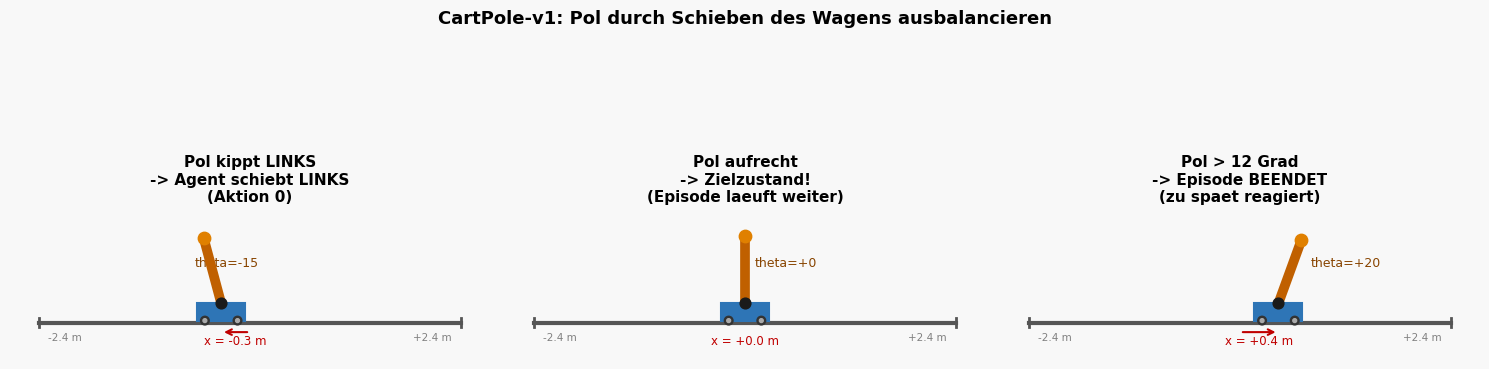

Zustandsvektor (4 Werte bei jedem Schritt):
  [x,   x_dot,   theta,   theta_dot]
  [Pos, Geschw., Winkel,  Winkelgeschw.]

Aktionen: 0 = LINKS   1 = RECHTS
Reward:   +1 pro ueberlebtem Schritt  |  Maximum: 500


In [2]:
def draw_cartpole(ax, x=0.0, theta_deg=0.0, title=""):
    theta = np.radians(theta_deg)

    # Schiene
    ax.plot([-2.2, 2.2], [0, 0], color='#555555', linewidth=3, zorder=1)
    ax.plot([-2.2, -2.2], [-0.05, 0.05], color='#555555', linewidth=2)
    ax.plot([ 2.2,  2.2], [-0.05, 0.05], color='#555555', linewidth=2)
    ax.text(-2.1, -0.18, '-2.4 m', fontsize=7.5, ha='left', color='gray')
    ax.text( 2.1, -0.18, '+2.4 m', fontsize=7.5, ha='right', color='gray')

    # Wagen
    cw, ch = 0.5, 0.18
    cart = plt.Rectangle((x - cw/2, 0.02), cw, ch,
                          color='#2E75B6', zorder=3, linewidth=1.5, edgecolor='#1A4A7A')
    ax.add_patch(cart)

    # Raeder
    for dx in [-0.17, 0.17]:
        ax.add_patch(plt.Circle((x + dx, 0.02), 0.045, color='#333333', zorder=4))
        ax.add_patch(plt.Circle((x + dx, 0.02), 0.020, color='#aaaaaa', zorder=5))

    # Pol
    pivot_y  = 0.02 + ch
    pole_len = 0.70
    px_end   = x + pole_len * np.sin(theta)
    py_end   = pivot_y + pole_len * np.cos(theta)
    ax.plot([x, px_end], [pivot_y, py_end],
            color='#C06000', linewidth=7, solid_capstyle='round', zorder=4)
    ax.scatter([x],      [pivot_y], color='#1A1A1A', s=60, zorder=6)
    ax.scatter([px_end], [py_end],  color='#E08000', s=80, zorder=6)

    # Winkel-Label
    sign = np.sign(theta_deg) if theta_deg != 0 else 1
    ax.text(px_end + 0.1 * sign, pivot_y + pole_len * 0.55,
            f'theta={theta_deg:+.0f}', fontsize=9, color='#884400')

    # Positions-Label
    ax.annotate('', xy=(x, -0.1), xytext=(0, -0.1),
                arrowprops=dict(arrowstyle='->', color='#C00000', lw=1.5))
    ax.text(x/2, -0.22, f'x = {x:+.1f} m', fontsize=8.5, ha='center', color='#C00000')

    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-0.38, 1.15)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.axis('off')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#F8F8F8')

draw_cartpole(axes[0], x=-0.3, theta_deg=-15,
              title='Pol kippt LINKS\n-> Agent schiebt LINKS\n(Aktion 0)')
draw_cartpole(axes[1], x=0.0,  theta_deg=0,
              title='Pol aufrecht\n-> Zielzustand!\n(Episode laeuft weiter)')
draw_cartpole(axes[2], x=0.4,  theta_deg=20,
              title='Pol > 12 Grad\n-> Episode BEENDET\n(zu spaet reagiert)')

for ax in axes:
    ax.set_facecolor('#F8F8F8')

plt.suptitle('CartPole-v1: Pol durch Schieben des Wagens ausbalancieren',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Zustandsvektor (4 Werte bei jedem Schritt):")
print("  [x,   x_dot,   theta,   theta_dot]")
print("  [Pos, Geschw., Winkel,  Winkelgeschw.]")
print()
print("Aktionen: 0 = LINKS   1 = RECHTS")
print("Reward:   +1 pro ueberlebtem Schritt  |  Maximum: 500")

# Schritt 4: CartPole-Umgebung erkunden

In [3]:
env = gym.make('CartPole-v1')
obs, _ = env.reset(seed=42)

print("CartPole-v1:")
print(f"  Zustandsraum: {env.observation_space}")
print(f"  Aktionsraum:  {env.action_space}")
print()
print("Startbeobachtung:")
print(f"  x      = {obs[0]:+.4f} m")
print(f"  x_dot  = {obs[1]:+.4f} m/s")
print(f"  theta  = {obs[2]:+.4f} rad  ({np.degrees(obs[2]):+.2f} Grad)")
print(f"  t_dot  = {obs[3]:+.4f} rad/s")
print()

print(f"{'Schritt':<8} {'Aktion':<8} {'x':>7} {'theta(Grad)':>12} {'Reward':>8} {'Done':>6}")
print("-" * 55)
for i in range(5):
    action = env.action_space.sample()
    obs, reward, term, trunc, _ = env.step(action)
    done = term or trunc
    print(f"{i+1:<8} {'LINKS' if action==0 else 'RECHTS':<8} "
          f"{obs[0]:>+7.3f} {np.degrees(obs[2]):>+12.2f} "
          f"{reward:>8.0f} {str(done):>6}")
env.close()

CartPole-v1:
  Zustandsraum: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
  Aktionsraum:  Discrete(2)

Startbeobachtung:
  x      = +0.0274 m
  x_dot  = -0.0061 m/s
  theta  = +0.0359 rad  (+2.05 Grad)
  t_dot  = +0.0197 rad/s

Schritt  Aktion         x  theta(Grad)   Reward   Done
-------------------------------------------------------
1        LINKS     +0.027        +2.08        1  False
2        LINKS     +0.023        +2.45        1  False
3        LINKS     +0.015        +3.17        1  False
4        LINKS     +0.003        +4.24        1  False
5        LINKS     -0.012        +5.66        1  False


# Schritt 5: Q-Werte und die Bellman-Gleichung

## Was ist ein Q-Wert?

Q(s, a) ist der **erwartete kumulierte Reward**, wenn der Agent im Zustand s
die Aktion a ausführt - und danach immer optimal handelt.

Beispiel:
- Q(Pol kippt rechts, rechts schieben) -> hoch (richtige Reaktion)
- Q(Pol kippt rechts, links schieben)  -> niedrig (falsche Reaktion)

## Die Bellman-Gleichung

Q(s, a) <- r + gamma * max_a' Q(s', a')

| Symbol | Bedeutung |
|--------|-----------|
| r | Reward dieses Schritts (+1 bei CartPole) |
| gamma | Diskontierung (0.99: Zukunft fast so wichtig wie Gegenwart) |
| s' | Nächster Zustand |
| max Q(s', a') | Bester Q-Wert im nächsten Zustand laut Target-Netz |

## Warum ein neuronales Netz?

CartPole hat 4 kontinuierliche Zustandsvariablen -> unendlich viele Zustände.
Eine Q-Tabelle wäre unendlich groß.

Das DQN approximiert die Q-Funktion:
Q(s, a) ~= NN(s)_a

Eingabe: 4 Zustandswerte -> Ausgabe: Q-Wert für jede der 2 Aktionen

# Schritt 6: Das neuronale Netz als Q-Funktion + Parameterberechnung

In [4]:
STATE_SIZE  = 4   # x, x_dot, theta, theta_dot
ACTION_SIZE = 2   # links, rechts

def build_q_network(state_size=STATE_SIZE, action_size=ACTION_SIZE, hidden=64):
    state_size  = int(state_size)
    action_size = int(action_size)
    inp = keras.Input(shape=(state_size,), name='state')
    x   = layers.Dense(hidden, activation='relu', name='hidden_1')(inp)
    x   = layers.Dense(hidden, activation='relu', name='hidden_2')(x)
    out = layers.Dense(action_size, activation='linear', name='q_output')(x)
    m   = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return m

q_net = build_q_network()
q_net.summary()

print()
print("=== Manuelle Parameterberechnung ===")
p1 = STATE_SIZE * 64 + 64
p2 = 64 * 64 + 64
p3 = 64 *  2 +  2
total = p1 + p2 + p3
print(f"Hidden 1:  {STATE_SIZE} x 64 + 64  = {p1:>5,}")
print(f"Hidden 2:  64 x 64 + 64           = {p2:>5,}")
print(f"Ausgabe:   64 x  2 +  2           = {p3:>5,}")
print(f"{'─'*38}")
print(f"Gesamt:                              {total:>5,}")
print(f"Pruefung mit summary(): {total:,} ✓")
print()
print(f"Vergleich: CNN (K10_04) hatte ~225.000 Parameter - {225034//total}x mehr als dieses DQN.")

env_t = gym.make('CartPole-v1')
ts    = env_t.reset(seed=0)[0]
env_t.close()
qv = q_net.predict(ts.reshape(1,-1), verbose=0)
print(f"\nTest-Q-Werte: links={qv[0][0]:.3f},  rechts={qv[0][1]:.3f}")
print("(Vor Training: zufaellige Werte)")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ state (InputLayer)              │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_output (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,610 (18.01 KB)

 Trainable params: 4,610 (18.01 KB)

 Non-trainable params: 0 (0.00 B)


=== Manuelle Parameterberechnung ===
Hidden 1:  4 x 64 + 64  =   320
Hidden 2:  64 x 64 + 64           = 4,160
Ausgabe:   64 x  2 +  2           =   130
──────────────────────────────────────
Gesamt:                              4,610
Pruefung mit summary(): 4,610 ✓

Vergleich: CNN (K10_04) hatte ~225.000 Parameter - 48x mehr als dieses DQN.

Test-Q-Werte: links=-0.013,  rechts=0.000
(Vor Training: zufaellige Werte)


# Schritt 7: Die drei Kernkomponenten des DQN

## Komponente 1: Experience Replay

Problem: Aufeinanderfolgende Schritte sind stark korreliert -> instabiles Training.

Lösung: Replay Buffer speichert (s, a, r, s', done) und liefert **zufällige Mini-Batches**.

```
Buffer:  [(s1,a1,r1,s2), (s2,a2,r2,s3), ..., (s9999,...)]
                     ↓ zufällige 32 Einträge
         [(s312,...), (s47,...), (s8,...)]  -> Bellman-Update
```

## Komponente 2: Target Network

Problem: Das Netz lernt gegen sich selbst - Zielwerte ändern sich nach jedem Update.

Lösung: Zwei Netze:
- **Q-Netz**: lernt laufend (jede Episode)
- **Target-Netz**: Kopie, aktualisiert nur alle N Episoden -> stabile Zielwerte

## Komponente 3: Epsilon-Greedy (wie K13_02!)

- Wahrscheinlichkeit epsilon -> zufällige Aktion (Exploration)
- Wahrscheinlichkeit 1-epsilon -> beste Aktion laut Q-Netz (Exploitation)
- epsilon nimmt ab: anfangs viel erkunden, später ausnutzen

# Schritt 8: DQN-Agent implementieren

In [5]:
class DQNAgent:
    # Deep Q-Network Agent fuer CartPole.
    # Drei Kernkomponenten: Replay Buffer, Q-/Target-Netz, Epsilon-Greedy.

    def __init__(self, state_size=STATE_SIZE, action_size=ACTION_SIZE,
                 gamma=0.99, epsilon=1.0, epsilon_min=0.01,
                 epsilon_decay=0.995, batch_size=32, target_update_freq=10):

        self.state_size         = int(state_size)
        self.action_size        = int(action_size)
        self.gamma              = gamma
        self.epsilon            = epsilon
        self.epsilon_min        = epsilon_min
        self.epsilon_decay      = epsilon_decay
        self.batch_size         = batch_size
        self.target_update_freq = target_update_freq

        # Komponente 1: Replay Buffer
        self.memory     = deque(maxlen=10_000)

        # Komponente 2: Q-Netz + Target-Netz
        self.q_net      = build_q_network()
        self.target_net = build_q_network()
        self.target_net.set_weights(self.q_net.get_weights())

    def act(self, state):
        # Komponente 3: Epsilon-Greedy
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.action_size)        # Exploration
        q = self.q_net(state.reshape(1,-1), training=False).numpy()
        return int(np.argmax(q[0]))                           # Exploitation

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def replay(self):
        if len(self.memory) < self.batch_size:
            return None

        batch       = random.sample(self.memory, self.batch_size)
        states      = np.array([e[0] for e in batch], dtype=np.float32)
        actions     = np.array([e[1] for e in batch], dtype=np.int32)
        rewards     = np.array([e[2] for e in batch], dtype=np.float32)
        next_states = np.array([e[3] for e in batch], dtype=np.float32)
        dones       = np.array([e[4] for e in batch], dtype=np.float32)

        # Bellman-Update via Target-Netz (stabile Zielwerte)
        q_values = self.q_net(states, training=False).numpy()
        q_next   = self.target_net(next_states, training=False).numpy()
        targets  = rewards + self.gamma * np.max(q_next, axis=1) * (1 - dones)
        q_values[np.arange(self.batch_size), actions] = targets

        loss = self.q_net.train_on_batch(states, q_values)

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

        return float(loss)

    def train_episode(self, env, max_steps=500):
        state, _ = env.reset()
        state    = state.astype(np.float32)
        total_r, losses = 0, []
        for step in range(max_steps):
            action                              = self.act(state)
            ns, reward, term, trunc, _          = env.step(action)
            ns   = ns.astype(np.float32)
            done = term or trunc
            self.remember(state, action, reward, ns, done)
            loss = self.replay()
            if loss is not None:
                losses.append(loss)
            state   = ns
            total_r += reward
            if done:
                break
        return total_r, step+1, float(np.mean(losses)) if losses else 0.0

print("DQNAgent definiert. Komponenten:")
print("  Replay Buffer (maxlen=10.000)")
print("  Q-Netz + Target-Netz")
print("  Epsilon-Greedy (1.0 -> 0.01)")

DQNAgent definiert. Komponenten:
  Replay Buffer (maxlen=10.000)
  Q-Netz + Target-Netz
  Epsilon-Greedy (1.0 -> 0.01)


# Schritt 9: Training
## DQN-Agent trainieren (ca. 4-6 Minuten in Colab)

In [6]:
env_train = gym.make('CartPole-v1')
agent = DQNAgent()

N_EPISODES = 150
rewards, steps_list, losses, epsilons = [], [], [], []

print(f"Training: {N_EPISODES} Episoden")
print(f"{'Episode':>8} {'Reward':>8} {'Avg50':>8} {'eps':>7} {'Loss':>10}  {'Zeit':>6}")
print("-" * 55)

t0 = time.time()
for ep in range(N_EPISODES):
    r, s, loss = agent.train_episode(env_train)
    rewards.append(r)
    steps_list.append(s)
    losses.append(loss)
    epsilons.append(agent.epsilon)

    if ep % agent.target_update_freq == 0:
        agent.target_net.set_weights(agent.q_net.get_weights())

    if ep % 25 == 0 or ep == N_EPISODES - 1:
        avg = np.mean(rewards[-50:])
        print(f"{ep:>8} {r:>8.0f} {avg:>8.1f} {agent.epsilon:>7.3f} "
              f"{loss:>10.4f}  {time.time()-t0:>5.0f}s")

env_train.close()
print(f"\nFertig in {time.time()-t0:.0f} Sekunden.")
print(f"Avg-Reward (letzte 50 Ep.): {np.mean(rewards[-50:]):.1f}")
print(f"Max. Reward:                {max(rewards):.0f}")

Training: 150 Episoden
 Episode   Reward    Avg50     eps       Loss    Zeit
-------------------------------------------------------
       0       26     26.0   1.000     0.0000      0s
      25       11     13.0   0.214     0.0945     10s
      50       23     13.8   0.032     0.1251     14s
      75       98     44.8   0.010     0.1398     40s
     100      186    116.4   0.010     0.1753     96s
     125      445    189.0   0.010     0.1888    173s
     149      251    257.4   0.010     0.1695    272s

Fertig in 272 Sekunden.
Avg-Reward (letzte 50 Ep.): 257.4
Max. Reward:                445


In [13]:
# CartPole-Animation direkt im Colab-Notebook
# Zeigt einen trainierten oder zufaelligen Agenten als Animation

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def animate_cartpole(agent=None, n_steps=300, seed=42, title="CartPole-Animation"):
    """
    Rendert eine CartPole-Episode als Animation.

    agent: DQNAgent (oder None fuer zufaellige Aktionen)
    n_steps: max. Schritte
    seed:    Zufallsstart
    """
    env = gym.make('CartPole-v1', render_mode='rgb_array')
    obs, _ = env.reset(seed=seed)
    frames, rewards_anim = [], []

    for step in range(n_steps):
        frame = env.render()
        frames.append(frame)

        if agent is not None:
            action = agent.act(obs.astype(np.float32))
        else:
            action = env.action_space.sample()

        obs, reward, term, trunc, _ = env.step(action)
        rewards_anim.append(reward)

        if term or trunc:
            frames.append(env.render())  # letztes Frame
            break

    env.close()

    # Animation erstellen
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.axis('off')
    im = ax.imshow(frames[0])
    step_text = ax.text(0.02, 0.95, '', transform=ax.transAxes,
                        fontsize=11, color='white',
                        bbox=dict(facecolor='black', alpha=0.5))

    def update(i):
        im.set_data(frames[i])
        step_text.set_text(f'Schritt {i+1}/{len(frames)}  |  '
                           f'Reward gesamt: {sum(rewards_anim[:i+1]):.0f}')
        return [im, step_text]

    ani = FuncAnimation(fig, update, frames=len(frames),
                        interval=40, blit=True, repeat=False)
    plt.title(title, fontsize=12)
    plt.tight_layout()
    plt.close()

    return HTML(ani.to_jshtml())


# ── Zufaelliger Agent (kein Training noetig) ───────────────────────────────
# print("Zufaelliger Agent:")
# animate_cartpole(agent=None, n_steps=80, title="Zufaelliger Agent – kein Training")

# ── Trainierter Agent (nach dem Training in Schritt 9 ausfuehren) ──────────
animate_cartpole(agent=agent, n_steps=300,
                 title=f"Trainierter DQN-Agent (Avg-Reward: {np.mean(rewards[-50:]):.0f})")


Output hidden; open in https://colab.research.google.com to view.

# Schritt 10: Lernkurven analysieren

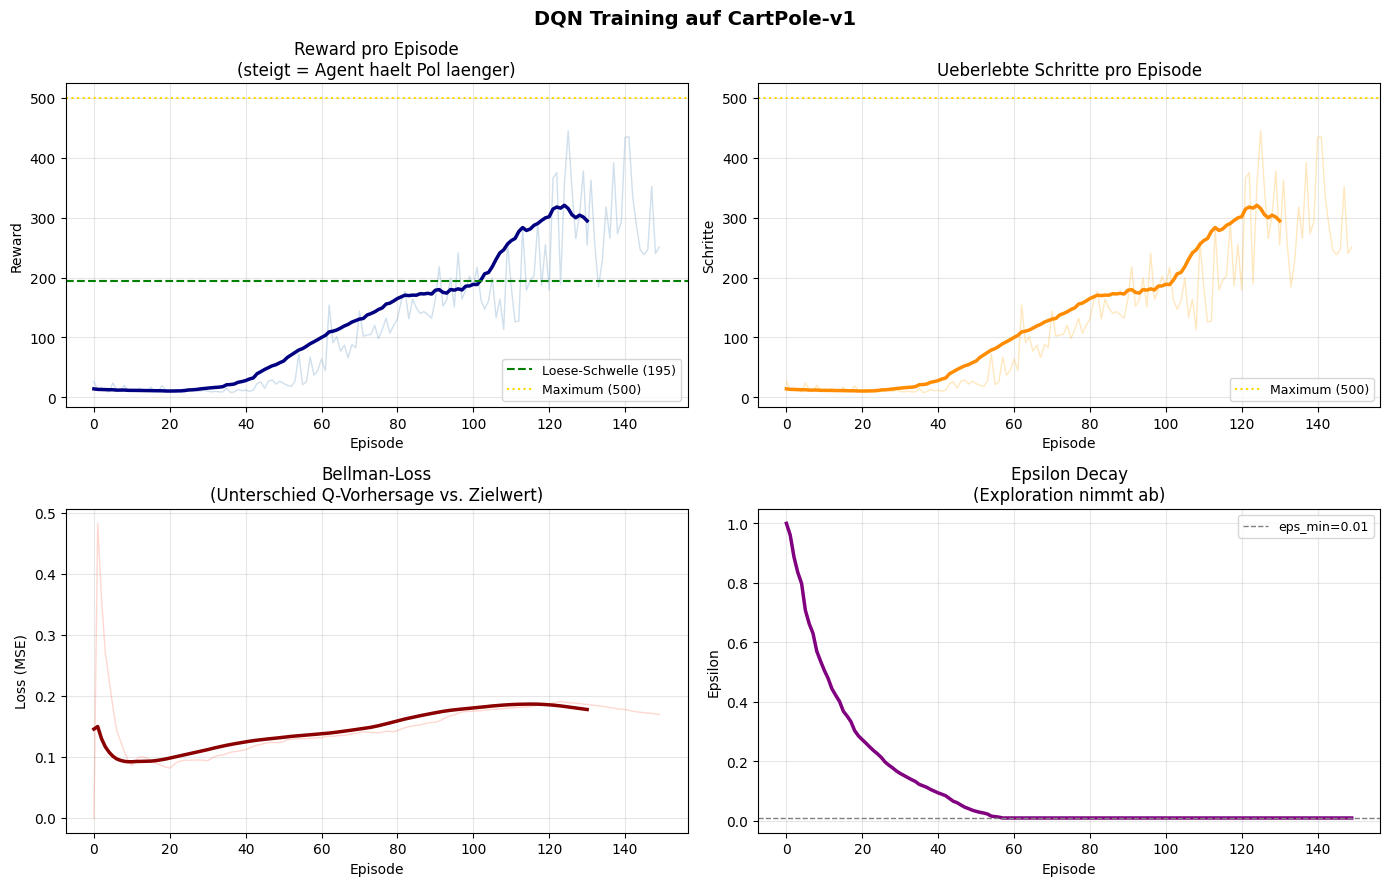

Leitfrage: Ab welcher Episode wird der Agent deutlich besser?


In [7]:
def smooth(data, w=20):
    return np.convolve(data, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0,0]
ax.plot(rewards, alpha=0.25, color='steelblue', linewidth=1)
ax.plot(range(len(smooth(rewards))), smooth(rewards), color='navy', linewidth=2.5)
ax.axhline(195, color='green', linestyle='--', linewidth=1.5, label='Loese-Schwelle (195)')
ax.axhline(500, color='gold',  linestyle=':',  linewidth=1.5, label='Maximum (500)')
ax.set_xlabel('Episode'); ax.set_ylabel('Reward')
ax.set_title('Reward pro Episode\n(steigt = Agent haelt Pol laenger)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[0,1]
ax.plot(steps_list, alpha=0.25, color='orange', linewidth=1)
ax.plot(range(len(smooth(steps_list))), smooth(steps_list), color='darkorange', linewidth=2.5)
ax.axhline(500, color='gold', linestyle=':', linewidth=1.5, label='Maximum (500)')
ax.set_xlabel('Episode'); ax.set_ylabel('Schritte')
ax.set_title('Ueberlebte Schritte pro Episode')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1,0]
ax.plot(losses, alpha=0.25, color='tomato', linewidth=1)
ax.plot(range(len(smooth(losses))), smooth(losses), color='darkred', linewidth=2.5)
ax.set_xlabel('Episode'); ax.set_ylabel('Loss (MSE)')
ax.set_title('Bellman-Loss\n(Unterschied Q-Vorhersage vs. Zielwert)')
ax.grid(True, alpha=0.3)

ax = axes[1,1]
ax.plot(epsilons, color='purple', linewidth=2.5)
ax.axhline(0.01, color='gray', linestyle='--', linewidth=1, label='eps_min=0.01')
ax.set_xlabel('Episode'); ax.set_ylabel('Epsilon')
ax.set_title('Epsilon Decay\n(Exploration nimmt ab)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('DQN Training auf CartPole-v1', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Leitfrage: Ab welcher Episode wird der Agent deutlich besser?")

# Schritt 11: Beobachtungsaufgaben

## Aufgabe A - Lernkurven lesen

1. Ab welcher Episode verbessert sich der Reward deutlich?
   Was passiert in dieser Phase mit Epsilon?

2. Warum ist der Loss am Anfang niedrig, steigt dann an und fällt wieder?
   (Hinweis: Am Anfang ist der Buffer fast leer - kaum Training.)

## Aufgabe B - Gamma-Einfluss (leicht)

Trainieren Sie einen zweiten Agenten mit gamma=0.5 statt 0.99.
Was bedeutet ein kleines Gamma fuer die Planung des Agenten?

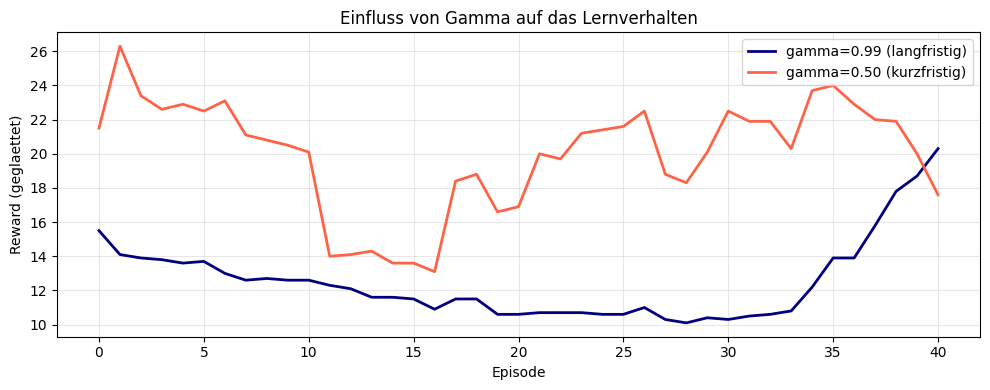

In [8]:
env_g = gym.make('CartPole-v1')
agent_low_g = DQNAgent(gamma=0.5)
rewards_low_g = []
for ep in range(50):
    r, _, _ = agent_low_g.train_episode(env_g)
    rewards_low_g.append(r)
    if ep % agent_low_g.target_update_freq == 0:
        agent_low_g.target_net.set_weights(agent_low_g.q_net.get_weights())
env_g.close()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(smooth(rewards[:50], 10), color='navy',   label='gamma=0.99 (langfristig)', linewidth=2)
ax.plot(smooth(rewards_low_g, 10), color='tomato', label='gamma=0.50 (kurzfristig)', linewidth=2)
ax.set_xlabel('Episode'); ax.set_ylabel('Reward (geglaettet)')
ax.set_title('Einfluss von Gamma auf das Lernverhalten')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Schritt 12: Aufgabe - Ohne Experience Replay (mittel)

Vergleichen Sie den Standard-DQN mit einem Agenten ohne Replay Buffer.
- Stabiler oder instabiler?
- Warum hilft der Replay Buffer?

Vervollständigen Sie die Klasse unten.

In [9]:
class OnlineDQNAgent:
    # DQN ohne Replay Buffer - lernt nach jedem Schritt direkt.

    def __init__(self, state_size=STATE_SIZE, action_size=ACTION_SIZE,
                 gamma=0.99, epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995):
        self.state_size    = int(state_size)
        self.action_size   = int(action_size)
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.q_net         = build_q_network()

    def act(self, state):
        # TODO: Epsilon-Greedy
        pass

    def update(self, state, action, reward, next_state, done):
        # TODO: Bellman-Update (kein Buffer, direktes train_on_batch)
        pass

    def train_episode(self, env, max_steps=500):
        # TODO: Episode + update() nach jedem Schritt
        pass

print("Vervollstaendigen Sie act(), update() und train_episode().")
print("Musterloesung: Schritt 13")

Vervollstaendigen Sie act(), update() und train_episode().
Musterloesung: Schritt 13


# Schritt 13: Musterloesung *(nur Dozenten-Version)*

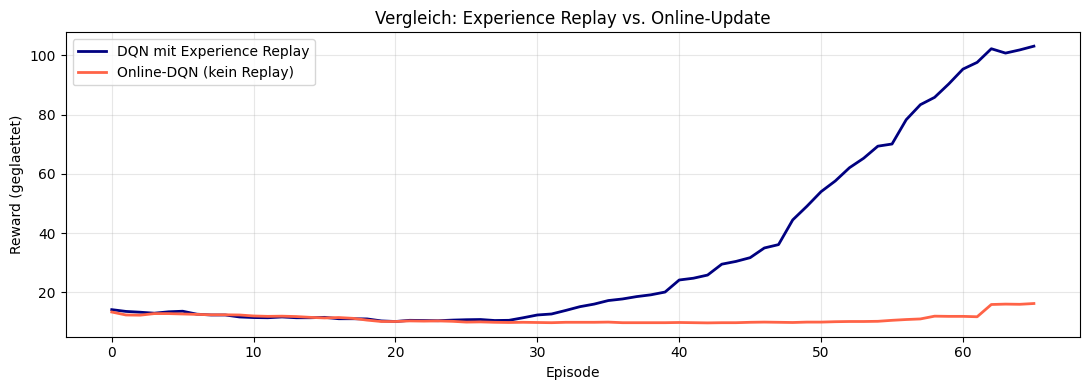

Erkenntnis: Experience Replay stabilisiert das Training, weil
  1. zufaellige Batches zeitliche Korrelationen aufbrechen
  2. Erfahrungen mehrfach genutzt werden
  3. das Target-Netz instabile Zielwerte verhindert


In [10]:
class OnlineDQNSolution:
    # Musterloesung: DQN ohne Replay Buffer.

    def __init__(self, state_size=STATE_SIZE, action_size=ACTION_SIZE,
                 gamma=0.99, epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995):
        self.state_size    = int(state_size)
        self.action_size   = int(action_size)
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.q_net         = build_q_network()

    def act(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.action_size)
        q = self.q_net(state.reshape(1,-1).astype(np.float32), training=False).numpy()
        return int(np.argmax(q[0]))

    def update(self, state, action, reward, next_state, done):
        s  = state.reshape(1,-1).astype(np.float32)
        ns = next_state.reshape(1,-1).astype(np.float32)
        q  = self.q_net(s,  training=False).numpy()
        qn = self.q_net(ns, training=False).numpy()
        q[0, action] = reward + self.gamma * np.max(qn) * (1 - float(done))
        self.q_net.train_on_batch(s, q)
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def train_episode(self, env, max_steps=500):
        state, _ = env.reset()
        state = state.astype(np.float32)
        total_r = 0
        for step in range(max_steps):
            a = self.act(state)
            ns, r, term, trunc, _ = env.step(a)
            ns   = ns.astype(np.float32)
            done = term or trunc
            self.update(state, a, r, ns, done)
            state   = ns
            total_r += r
            if done:
                break
        return total_r, step + 1

env_c = gym.make('CartPole-v1')
online = OnlineDQNSolution()
online_r = []
for ep in range(80):
    r, _ = online.train_episode(env_c)
    online_r.append(r)
env_c.close()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(smooth(rewards[:80], 15), color='navy',   linewidth=2, label='DQN mit Experience Replay')
ax.plot(smooth(online_r,     15), color='tomato', linewidth=2, label='Online-DQN (kein Replay)')
ax.set_xlabel('Episode'); ax.set_ylabel('Reward (geglaettet)')
ax.set_title('Vergleich: Experience Replay vs. Online-Update')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Erkenntnis: Experience Replay stabilisiert das Training, weil")
print("  1. zufaellige Batches zeitliche Korrelationen aufbrechen")
print("  2. Erfahrungen mehrfach genutzt werden")
print("  3. das Target-Netz instabile Zielwerte verhindert")

# Schritt 14: Merksatz

## Zusammenfassung

| Konzept | Kernaussage |
|---------|-------------|
| **Q-Wert** | Erwarteter kumulierter Reward fuer Aktion a in Zustand s |
| **Bellman** | Q(s,a) <- r + gamma * max Q(s',a') |
| **DQN** | Neuronales Netz approximiert Q-Funktion fuer kont. Zustandsraeume |
| **Experience Replay** | Zufaellige Mini-Batches -> stabiles Lernen |
| **Target Network** | Stabile Zielwerte -> verhindert Instabilitaet |
| **Epsilon Decay** | Exploration nimmt ab, wie beim Einarmigen Banditen (K13_02) |

## Merksatz

**DQN = Q-Learning + neuronales Netz + Experience Replay + Target Network.**
Erst das Zusammenspiel aller drei Techniken macht stabiles Training moeglich.

## Ausblick

| Methode | Verbesserung |
|---------|-------------|
| Double DQN | Verhindert Ueberschaetzung der Q-Werte |
| Dueling DQN | Trennt Zustands- und Aktionswert |
| PPO | State-of-the-Art (RLHF bei ChatGPT/Claude nutzt Varianten!) |